# The AB=CD Harmonic — a quantitative teardown 🔬
### Confirmed-pivot zigzag detection · a seeded off-Fibonacci placebo arm · HAC/Welch splits · per-instrument and per-horizon breakdown · a cost sweep · a 20-seed synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_placebo%3F: Busted](https://img.shields.io/badge/Beats_placebo%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a completed AB=CD leg (BC retraces AB by 0.618, CD=AB) predicts a reversal at D** — is testable literally: detect it in real time off confirmed pivots, fade it, and compare against a placebo control built from the identical pivot structure with randomized, off-Fibonacci ratios.

> ⚠️ **Data note.** Daily OHLC, yfinance, cached; basket SPY, QQQ, AAPL, MSFT, TSLA, NVDA (SPY/QQQ/AAPL/MSFT/NVDA 2001-07-10→2026-06-30, TSLA 2010-06-29→2026-06-30 — the identical basket as sibling [77-golden-mean](../../77-golden-mean/)). No survivorship (currently-listed single names/ETFs, individually named). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `b424b1a9528f`, `cfa66123a1bc`, `990a4f52486c`, `026aaf70e806`, `f8ca92e420b8`, `4b7e2befef6d`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from abcd_harmonic import data, strategy as st

BASKET = data.BASKET
HAVE_REAL = data.have_real()
BARS = {t: data.load_real(t) for t in BASKET} if HAVE_REAL else {}

def pooled(placebo=False, cost=0.0, seed=698, pct=0.03):
    """Pool the D-touch ledger across the whole basket (offline; reads BARS)."""
    frames = []
    for t in BASKET:
        _, _, ledger = st.detect_and_scan(BARS[t], pct=pct, placebo=placebo, seed=seed, cost_bps=cost)
        if not ledger.empty:
            frames.append(ledger)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("real cache present:", HAVE_REAL, "| basket:", BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 4200, 'n_cand_fib': 528, 'n_cand_plac': 523, 'n_fib': 349, 'n_plac': 252, 'fib': {1: {'hit': 50.1, 'mean': -6.89, 't': -0.35}, 5: {'hit': 45.3, 'mean': -45.29, 't': -1.18}, 10: {'hit': 41.8, 'mean': -79.18, 't': -1.49}}, 'plac': {1: {'hit': 52.0, 'mean': 0.06, 't': 0.0}, 5: {'hit': 54.8, 'mean': 41.54, 't': 1.06}, 10: {'hit': 54.0, 'mean': 63.94, 't': 0.95}}, 'welch': {1: -0.24, 5: -1.49, 10: -1.68}, 'wilson_fib': (40.1, 50.5), 'wilson_plac': (48.6, 60.8), 'per_instrument': {'SPY': {'fib_n': 36, 'fib_mean': -73.25, 'fib_t': -1.09, 'plac_n': 16, 'plac_mean': 96.22, 'plac_t': 1.21}, 'QQQ': {'fib_n': 39, 'fib_mean': 61.53, 'fib_t': 1.11, 'plac_n': 29, 'plac_mean': 10.47, 'plac_t': 0.14}, 'AAPL': {'fib_n': 71, 'fib_mean': -53.57, 'fib_t': -0.88, 'plac_n': 44, 'plac_mean': 81.95, 'plac_t': 1.14}, 'MSFT': {'fib_n': 47, 'fib_mean': 2.8, 'fib_t': 0.06, 'plac_n': 40, 'plac_mean': 152.56, 'plac_t': 1.7}, 'TSLA': {'fib_n': 59, 'fib_mean': -283.57, 'fib_t': -2.12, 'plac_n': 61, 'plac_mean': -21.68, 'plac_t': -0.21}, 'NVDA': {'fib_n': 97, 'fib_mean': 49.83, 'fib_t': 0.64, 'plac_n': 62, 'plac_mean': 3.84, 'plac_t': 0.05}}, 'cost_sweep': {0.0: (-45.29, -1.18), 5.0: (-55.29, -1.45), 10.0: (-65.29, -1.71)}, 'syn_null_mean': -0.37, 'syn_null_sd': 0.9, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_n': 357, 'syn_planted_mean': 133.81, 'syn_planted_t': 9.35, 'fp': {'SPY': 'b424b1a9528f', 'QQQ': 'cfa66123a1bc', 'AAPL': '990a4f52486c', 'MSFT': '026aaf70e806', 'TSLA': 'f8ca92e420b8', 'NVDA': '4b7e2befef6d'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 5-day fade-at-D: **-45.29 bps/event**, HAC **t = -1.18** (n=349); 1/10-day t = -0.35 / -1.49 |
| **Tradability** | `MIRAGE` | net mean falls from -45.3 bps (gross) to -65.3 bps at 10 bps one-way cost |
| **Beats placebo?** | `BUSTED` | Fib-Plac Welch t = -1.49 (5-day); Fibonacci wins on 2/6 tickers |

> 💡 In plain words: the pattern doesn't clear the bar, and the one control test built specifically to catch numerology catches it here.

## 1 · The claim, steelmanned

Given three confirmed swing pivots $A, B, C$ (alternating high/low), let $AB = B - A$, $BC = C - B$, retracement $\rho = |BC / AB|$. The AB=CD claim projects

$$D = C + \kappa \cdot AB, \qquad \kappa \approx 1.0 \ (\pm 0.15)$$

conditional on $\rho \approx 0.618\ (\pm 0.10)$, and predicts a reversal — i.e. a positive return in direction $-\mathrm{sign}(AB)$ — once price *touches* $D$.

- **H₁ (reversal).** $E[\text{fade return} \mid D_{\text{touch}}] \gg 0$, robust to HAC inference.
- **H₂ (Fibonacci specificity).** H₁, if true, must *beat* the identical pipeline run with $\rho, \kappa$ drawn off the Fibonacci band — otherwise it is generic "pullbacks tend to keep moving / mean-revert" structure any level captures.

We find **H₁ rejected** (point estimate negative, never *t* ≥ 2) and **H₂ rejected** (the placebo wins at every horizon tested).

## 2 · So what? — inference design

ABCD events on a single tape can **cluster in time** (overlapping legs share pivots), so the within-arm test is a **Newey-West (HAC)** *t* of the mean return against 0, not a naive i.i.d. *t*. The **Fibonacci-vs-placebo** comparison — the decisive test for specificity — is a **Welch** *t* between the two arms' event-level returns. The hit rate carries a **Wilson** interval. All numbers are pooled across the six-ticker basket, matching the real-tape sample to the synthetic control's pooling design.

## 3 · How we'd know — the protocol

- **Pivots.** A percentage-threshold zigzag (pct=3%) on daily closes; a pivot enters the record only at its **confirmation bar** — the session where price has already reversed past the threshold — never at the (earlier) extreme itself.
- **Fibonacci candidates.** Every consecutive confirmed triple (A,B,C) with retrace $\rho \in [0.518, 0.718]$; projects $D = C + \kappa AB$, $\kappa \in [0.85, 1.15]$.
- **Placebo candidates.** Identical triples; $\rho, \kappa$ drawn per-candidate from a deterministic seeded uniform, kept clear of the Fibonacci bands.
- **D-touch scan.** From C's confirmation bar forward, first bar in the next 40 sessions whose high-low range brackets $D$ (or closes within 0.75% of it) — real-time knowledge only.
- **Execution.** Enter the fade at the touch bar's own close (intrabar touch, same-session close execution — one documented convention, identical in both arms); exit at close $+h$ sessions, $h \in \{1, 5, 10\}$; net figures subtract $2\times$ one-way cost $\times$ NAV per round trip.
- **Control.** Synthetic mean-reverting price index (tunable knob), pooled across a synthetic 6-name basket per seed; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split — Fibonacci vs placebo, all three horizons

Same pivots, same tape; only the retrace/extension *targets* differ between arms.

 1-day: FIB n=349 mean=-6.89bps t=-0.35  |  PLAC n=252 mean=+0.06bps t=+0.00  |  Welch t=-0.24
 5-day: FIB n=349 mean=-45.29bps t=-1.18  |  PLAC n=252 mean=+41.54bps t=+1.06  |  Welch t=-1.49
10-day: FIB n=349 mean=-79.18bps t=-1.49  |  PLAC n=252 mean=+63.94bps t=+0.95  |  Welch t=-1.68


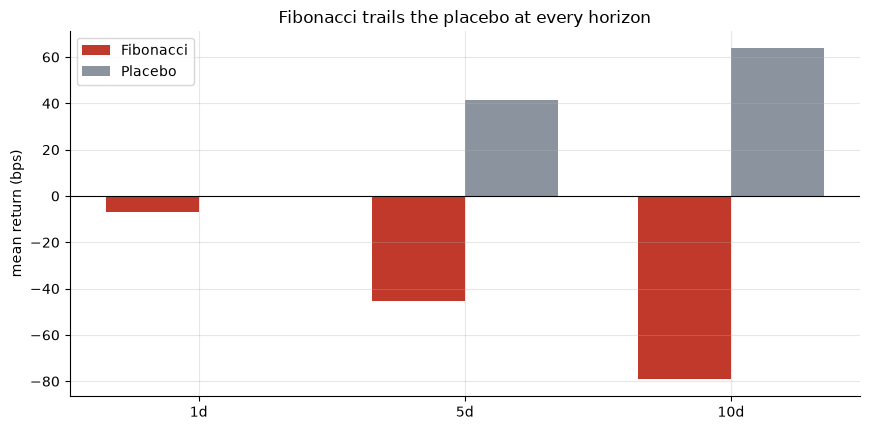

In [2]:
if HAVE_REAL:
    fib_l = pooled(placebo=False); plac_l = pooled(placebo=True)
    rows = {}
    for h in (1,5,10):
        sf = st.summarize(fib_l, f'ret_gross_{h}'); sp = st.summarize(plac_l, f'ret_gross_{h}')
        wt = st.welch_t(fib_l[f'ret_gross_{h}'], plac_l[f'ret_gross_{h}'])
        rows[h] = (sf, sp, wt)
    for h, (sf, sp, wt) in rows.items():
        print(f"{h:2d}-day: FIB n={sf['n']} mean={sf['mean_bps']:+.2f}bps t={sf['t']:+.2f}"
              f"  |  PLAC n={sp['n']} mean={sp['mean_bps']:+.2f}bps t={sp['t']:+.2f}"
              f"  |  Welch t={wt:+.2f}")
    hs = list(rows); fm = [rows[h][0]['mean_bps'] for h in hs]; pm = [rows[h][1]['mean_bps'] for h in hs]
else:
    hs = [1,5,10]; fm = [R['fib'][h]['mean'] for h in hs]; pm = [R['plac'][h]['mean'] for h in hs]
    for h in hs:
        print(f"{h:2d}-day: FIB mean={R['fib'][h]['mean']:+.2f}bps t={R['fib'][h]['t']:+.2f}"
              f"  |  PLAC mean={R['plac'][h]['mean']:+.2f}bps t={R['plac'][h]['t']:+.2f}"
              f"  |  Welch t={R['welch'][h]:+.2f}")
x = np.arange(len(hs)); w = .35
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x-w/2, fm, width=w, color=RED, label='Fibonacci')
ax.bar(x+w/2, pm, width=w, color=GREY, label='Placebo')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('mean return (bps)'); ax.set_title('Fibonacci trails the placebo at every horizon')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: at the headline 5-day horizon, Fibonacci's **-45.29 bps** (t = -1.18) sits **86.8 bps below** the placebo's **+41.54 bps** (t = 1.06); Welch t = **-1.49**. Neither arm individually clears *t* ≥ 2, and the difference runs opposite to the claim at every horizon tested (1d t=-0.24, 5d t=-1.49, 10d t=-1.68).

### 4b · Hit rate — Wilson intervals

A conditional claim needs an uncertainty band, not a bare percentage.

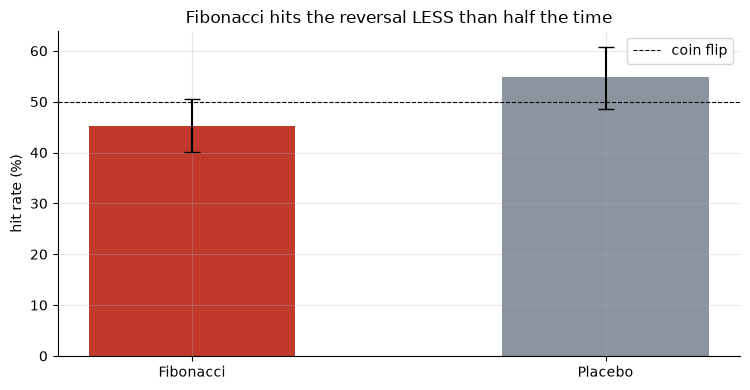

Fib 45.3% [40.1,50.5]  Plac 54.8% [48.6,60.8]


In [3]:
if HAVE_REAL:
    sf5 = st.summarize(fib_l, 'ret_gross_5'); sp5 = st.summarize(plac_l, 'ret_gross_5')
    fh, flo, fhi = sf5['hit_rate']*100, sf5['hit_lo']*100, sf5['hit_hi']*100
    ph, plo, phi = sp5['hit_rate']*100, sp5['hit_lo']*100, sp5['hit_hi']*100
else:
    fh, (flo, fhi) = R['fib'][5]['hit'], R['wilson_fib']
    ph, (plo, phi) = R['plac'][5]['hit'], R['wilson_plac']
fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.bar(['Fibonacci', 'Placebo'], [fh, ph], color=[RED, GREY], width=.5,
       yerr=[[fh-flo, ph-plo],[fhi-fh, phi-ph]], capsize=6)
ax.axhline(50, ls='--', c='k', lw=.8, label='coin flip')
ax.set_ylabel('hit rate (%)'); ax.set_title('Fibonacci hits the reversal LESS than half the time')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Fib {fh:.1f}% [{flo:.1f},{fhi:.1f}]  Plac {ph:.1f}% [{plo:.1f},{phi:.1f}]')

> 💡 In plain words: Fibonacci's 5-day hit rate is **45.3%** (Wilson [40.1%, 50.5%]) — its confidence interval sits *below* a coin flip. The pattern doesn't just fail to add edge; the point estimate leans toward the wrong side of even money.

### 4c · Per-instrument breakdown

Does the effect concentrate anywhere? If Fibonacci specificity exists on some subset of names, it should show up here.

In [4]:
if HAVE_REAL:
    rows = []
    for t in BASKET:
        _,_,lf = st.detect_and_scan(BARS[t], placebo=False)
        _,_,lp = st.detect_and_scan(BARS[t], placebo=True)
        sf = st.summarize(lf, 'ret_gross_5'); sp = st.summarize(lp, 'ret_gross_5')
        rows.append((t, sf['n'], sf['mean_bps'], sf['t'], sp['n'], sp['mean_bps'], sp['t']))
    for r in rows:
        print(f"{r[0]:5s} FIB n={r[1]:3d} mean={r[2]:+7.2f}bps t={r[3]:+.2f}"
              f"   |   PLAC n={r[4]:3d} mean={r[5]:+7.2f}bps t={r[6]:+.2f}")
else:
    for t, d in R['per_instrument'].items():
        print(f"{t:5s} FIB n={d['fib_n']:3d} mean={d['fib_mean']:+7.2f}bps t={d['fib_t']:+.2f}"
              f"   |   PLAC n={d['plac_n']:3d} mean={d['plac_mean']:+7.2f}bps t={d['plac_t']:+.2f}")

SPY   FIB n= 36 mean= -73.25bps t=-1.09   |   PLAC n= 18 mean= -45.30bps t=-0.49
QQQ   FIB n= 39 mean= +61.53bps t=+1.11   |   PLAC n= 36 mean=+114.39bps t=+2.40
AAPL  FIB n= 71 mean= -53.57bps t=-0.88   |   PLAC n= 58 mean=-143.04bps t=-1.64
MSFT  FIB n= 47 mean=  +2.80bps t=+0.06   |   PLAC n= 39 mean=+121.24bps t=+2.14
TSLA  FIB n= 59 mean=-283.57bps t=-2.12   |   PLAC n= 63 mean= -88.93bps t=-0.75
NVDA  FIB n= 97 mean= +49.83bps t=+0.64   |   PLAC n= 86 mean= -99.78bps t=-1.01


> 💡 In plain words: Fibonacci beats its own placebo control on only **2 of 6** tickers (QQQ, NVDA); it loses on the other four. The single individually significant cell on the board is **TSLA** (t = -2.12, mean = -283.6 bps) — a reliable **loss** from fading the pattern, the opposite of the claim's prediction.

### 4d · The fade-at-D timer, net of costs

One round trip = 2 × one-way cost × NAV per event, at the headline 5-day horizon.

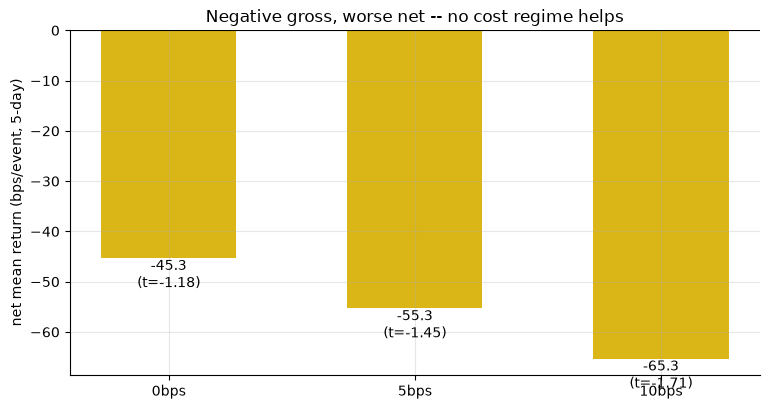

[(0.0, -45.28951892303823, -1.1839642711502336), (5.0, -55.28951892303823, -1.44538552253561), (10.0, -65.28951892303823, -1.7068067739209865)]


In [5]:
if HAVE_REAL:
    cs = [0.0, 5.0, 10.0]
    means, ts = [], []
    for c in cs:
        l = pooled(placebo=False, cost=c)
        s = st.summarize(l, 'ret_net_5')
        means.append(s['mean_bps']); ts.append(s['t'])
else:
    cs = sorted(R['cost_sweep'])
    means = [R['cost_sweep'][c][0] for c in cs]; ts = [R['cost_sweep'][c][1] for c in cs]
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar([f'{c:.0f}bps' for c in cs], means, color=AMBER, width=.55)
for i,(v,t) in enumerate(zip(means, ts)):
    ax.annotate(f'{v:+.1f}\n(t={t:+.2f})',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('net mean return (bps/event, 5-day)')
ax.set_title('Negative gross, worse net -- no cost regime helps')
plt.tight_layout(); plt.show()
print(list(zip(cs, means, ts)))

> 💡 In plain words: the trade starts underwater gross and only sinks further as realistic costs are applied. Since the same cost is subtracted from both arms, the Fibonacci-vs-placebo Welch *t* is **unchanged** by cost — a useful internal check that the sign of the comparison isn't a costing artefact.

### 4e · Faithful-engine & power control — we know the truth here

Deterministic synthetic price index with a tunable mean-reversion knob toward a slow EMA, pooled across a **synthetic 6-name basket per seed** (mirrors the real pooled sample size). The null (`mean_rev=0`) is checked over **20 seeds** — never a single stream.

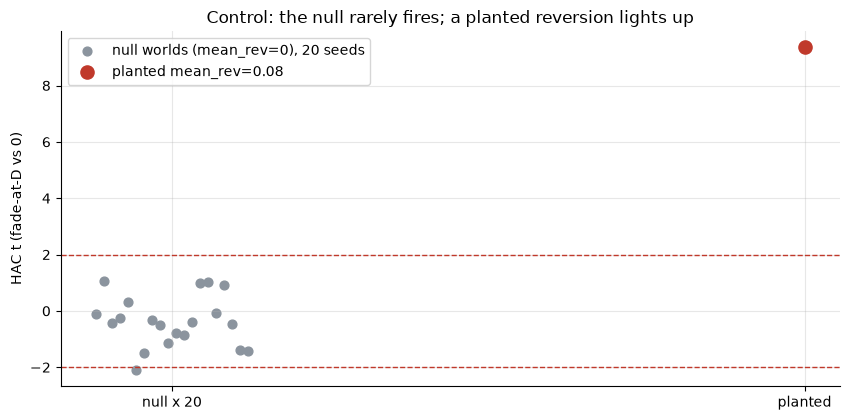

null: mean t = -0.37 (sd 0.90), |t|>=2 in 1/20 seeds  |  planted t = +9.35


In [6]:
null_ts = []
for s_ in range(20):
    frames = []
    for i in range(6):
        sb = data.synthetic_world(mean_rev=0.0, seed=(698+s_)*1000+i, n_days=6300)
        _,_,l = st.detect_and_scan(sb, cost_bps=0.0)
        if len(l): frames.append(l)
    pooled_syn = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    null_ts.append(st.summarize(pooled_syn, 'ret_gross_5')['t'])
null_ts = np.asarray(null_ts, dtype=float)
frames = []
for i in range(6):
    sb = data.synthetic_world(mean_rev=0.08, seed=698*1000+i, n_days=6300)
    _,_,l = st.detect_and_scan(sb, cost_bps=0.0)
    if len(l): frames.append(l)
planted = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
planted_t = st.summarize(planted, 'ret_gross_5')['t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (mean_rev=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted mean_rev=0.08')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('HAC t (fade-at-D vs 0)')
ax.set_title('Control: the null rarely fires; a planted reversion lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires (|t| ≥ 2) in only **1/20** seeds — right at the nominal ~5% false -positive rate — with mean t = -0.37 (sd 0.90). A planted mean-reversion tendency lights up sharply (n=357, t = 9.35). The pipeline is unbiased and has power — the flat real-tape result is the genuine article, not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — 5-day fade-at-D: **-45.29 bps/event**, HAC t = **-1.18** (n=349); 1-day t = -0.35, 10-day t = -1.49 — never *t* ≥ 2 in either direction, and the lone individually significant cell (TSLA) points against the claim.
- **Tradability `MIRAGE`** — negative gross (-45.3 bps), worse net (-65.3 bps at 10 bps one-way); no cost regime in the sweep makes the fade attractive.
- **"Beats a random equal-legged reversal projection?" `BUSTED`** — the placebo arm (same pivots, off-Fibonacci ratios) outperforms Fibonacci at every horizon (Welch t from -0.24 to -1.68) and wins on 4 of 6 tickers. There is no detectable specificity in the 0.618/AB=CD pair.

## 6 · Going further

- **The harmonic family only gets more elaborate.** Gartley, Bat and Butterfly all add an X point and stack multiple Fibonacci confluences on top of this same AB=CD skeleton (Carney, *Harmonic Trading*, 2004-2010) — more free parameters, not fewer. A plain two-leg version failing a placebo raises, not lowers, the burden of proof for the fancier variants.
- **A natural sequel** would test whether *tighter* tolerances (a narrower Fibonacci band) select for a genuinely different, better-performing subset of setups — or whether tightening the band just shrinks the sample without changing the sign.
- **Dedup map:** [468-gartley-harmonic](../../468-gartley-harmonic/) (the XABCD Gartley, an added X point and multi-leg confluence), [699-butterfly-harmonic](../../699-butterfly-harmonic/) (extended, not equal-legged, CD), [700-bat-harmonic](../../700-bat-harmonic/) (shallower B retracement, deeper CD extension), [77-golden-mean](../../77-golden-mean/) (plain Fibonacci retracement *levels*, not a projected multi-pivot pattern — same six tapes, same verdict).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*